# Recomendación Online: GNNs con Items Cold-Start (Versión Mejorada)

**Dataset:** Twitter15 + Twitter16 (split temporal global)  
**Escenario:** Recomendar tweets NUEVOS (publicados después del cutoff temporal)

En este notebook aplicamos mejoras arquitecturales y de training para mejorar el MRR de cada modelo:
- **GCN-BERT mejorado:** MPNet (768-dim), projection más profunda, BatchNorm, Dropout, 4 capas
- **GCN-Random mejorado:** Embeddings de 128-dim entrenables, arquitectura más profunda
- **LightGCN mejorado:** Projection propia para cold-start, normalización por capa

**Mejoras de training:**
- Hard negative mining (30% hard, 70% random)
- Learning rate scheduler con warm restarts
- Gradient clipping
- Early stopping con validation split
- Sample weighting por interaction_count
- Text preprocessing para BERT

Objetivo: maximizar MRR de cada modelo sin intervenir en la exposición a fake news.

## Setup y descarga de datos

In [3]:
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_round2/twitter15_processed.csv
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_round2/twitter16_processed.csv
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_round2/negative_samples.csv

print("Datos descargados")

Datos descargados


In [4]:
import pandas as pd
import numpy as np
import re
from html import unescape
from pathlib import Path

def decode_snowflake_timestamp(tweet_id):
    try:
        timestamp_ms = ((int(tweet_id) >> 22) + 1288834974657)
        return pd.to_datetime(timestamp_ms, unit='ms')
    except:
        return pd.NaT

print("Generando split temporal global...")
for dataset in ['twitter15', 'twitter16']:
    df = pd.read_csv(f'{dataset}_processed.csv', sep=';')
    df['timestamp'] = df['child_tweet_id'].apply(decode_snowflake_timestamp)
    df['child_datetime'] = pd.to_datetime(df['child_datetime'])
    df['timestamp'] = df['timestamp'].fillna(df['child_datetime'])

    df_collapsed = df.groupby(['child_user_id', 'source_tree_id']).agg({
        'timestamp': 'min',
        'text': 'first',
        'parent_label': 'first',
        'tree_label': 'first',
        'child_tweet_id': 'size'
    }).reset_index()

    df_collapsed.rename(columns={'child_tweet_id': 'interaction_count'}, inplace=True)
    df_collapsed['interaction_count'] = df_collapsed['interaction_count'].clip(upper=10)

    cutoff_T = df_collapsed['timestamp'].sort_values().quantile(0.7)
    cutoff_V = df_collapsed['timestamp'].sort_values().quantile(0.8)

    df_collapsed['split'] = 'test'
    df_collapsed.loc[df_collapsed['timestamp'] < cutoff_V, 'split'] = 'val'
    df_collapsed.loc[df_collapsed['timestamp'] < cutoff_T, 'split'] = 'train'

    df_collapsed.to_csv(f'{dataset}_temporal.csv', sep=';', index=False)
    print(f"  {dataset}: {len(df_collapsed)} interacciones")

print("Split temporal creado (70/10/20)")

Generando split temporal global...
  twitter15: 74260 interacciones
  twitter16: 30059 interacciones
Split temporal creado (70/10/20)


In [5]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q torch-geometric
!pip install -q sentence-transformers
!pip install -q scipy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, LGConv
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import random
from collections import defaultdict
from sentence_transformers import SentenceTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

Device: cuda


## Cargar datos con split temporal (train/val/test)

Creamos validation split para early stopping.

In [6]:
df15 = pd.read_csv('twitter15_temporal.csv', sep=';')
df16 = pd.read_csv('twitter16_temporal.csv', sep=';')
df = pd.concat([df15, df16], ignore_index=True)

print(f"Total interacciones: {len(df):,}")
print(f"Usuarios: {df['child_user_id'].nunique():,}")
print(f"Items: {df['source_tree_id'].nunique():,}")
print(f"\nSplits:")
print(f"  Train: {(df['split']=='train').sum():,}")
print(f"  Val:   {(df['split']=='val').sum():,}")
print(f"  Test:  {(df['split']=='test').sum():,}")

train_df = df[df['split'] == 'train'].reset_index(drop=True)
val_df = df[df['split'] == 'val'].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

train_items = set(train_df['source_tree_id'].unique())
val_items = set(val_df['source_tree_id'].unique())
test_items = set(test_df['source_tree_id'].unique())

print(f"\nVerificación cold-start:")
print(f"  Items en train: {len(train_items):,}")
print(f"  Items en val (cold): {len(val_items - train_items):,} / {len(val_items):,}")
print(f"  Items en test (cold): {len(test_items - train_items):,} / {len(test_items):,}")

Total interacciones: 104,319
Usuarios: 39,958
Items: 1,386

Splits:
  Train: 72,809
  Val:   10,619
  Test:  20,891

Verificación cold-start:
  Items en train: 942
  Items en val (cold): 168 / 190
  Items en test (cold): 287 / 300


## Crear mappings

Mapeamos users e items a índices. Solo items de train van al grafo.

In [7]:
all_users = sorted(df['child_user_id'].unique())
train_items_list = sorted(train_items)
val_items_cold = sorted(val_items - train_items)
test_items_cold = sorted(test_items - train_items)

user_to_idx = {uid: idx for idx, uid in enumerate(all_users)}
item_to_idx_train = {iid: idx for idx, iid in enumerate(train_items_list)}
item_to_idx_val = {iid: idx for idx, iid in enumerate(val_items_cold)}
item_to_idx_test = {iid: idx for idx, iid in enumerate(test_items_cold)}

num_users = len(user_to_idx)
num_train_items = len(item_to_idx_train)
num_val_items = len(item_to_idx_val)
num_test_items = len(item_to_idx_test)

print(f"Mappings creados:")
print(f"  Usuarios: {num_users:,}")
print(f"  Items train: {num_train_items:,}")
print(f"  Items val (cold): {num_val_items:,}")
print(f"  Items test (cold): {num_test_items:,}")

train_df['user_idx'] = train_df['child_user_id'].map(user_to_idx)
train_df['item_idx'] = train_df['source_tree_id'].map(item_to_idx_train)
train_df = train_df.dropna(subset=['user_idx', 'item_idx']).reset_index(drop=True)
train_df['user_idx'] = train_df['user_idx'].astype(int)
train_df['item_idx'] = train_df['item_idx'].astype(int)

val_df['user_idx'] = val_df['child_user_id'].map(user_to_idx)
val_df['item_idx_cold'] = val_df['source_tree_id'].map(item_to_idx_val)
val_df = val_df.dropna(subset=['user_idx', 'item_idx_cold']).reset_index(drop=True)
val_df['user_idx'] = val_df['user_idx'].astype(int)
val_df['item_idx_cold'] = val_df['item_idx_cold'].astype(int)

test_df['user_idx'] = test_df['child_user_id'].map(user_to_idx)
test_df['item_idx_cold'] = test_df['source_tree_id'].map(item_to_idx_test)
test_df = test_df.dropna(subset=['user_idx', 'item_idx_cold']).reset_index(drop=True)
test_df['user_idx'] = test_df['user_idx'].astype(int)
test_df['item_idx_cold'] = test_df['item_idx_cold'].astype(int)

print(f"\nInteracciones después de mapear:")
print(f"  Train: {len(train_df):,}")
print(f"  Val: {len(val_df):,}")
print(f"  Test: {len(test_df):,}")

Mappings creados:
  Usuarios: 39,958
  Items train: 942
  Items val (cold): 168
  Items test (cold): 287

Interacciones después de mapear:
  Train: 72,809
  Val: 10,579
  Test: 20,864


## Construir grafo bipartito (solo train)

El grafo social no se usa en este notebook pero lo dejamos para análisis de propagación.

In [8]:
user_indices = torch.tensor(train_df['user_idx'].values, dtype=torch.long)
item_indices = torch.tensor(train_df['item_idx'].values, dtype=torch.long)
item_shifted = item_indices + num_users

train_edge_index = torch.stack([
    torch.cat([user_indices, item_shifted]),
    torch.cat([item_shifted, user_indices])
], dim=0).to(device)

print(f"Grafo bipartito (train):")
print(f"  Nodos: {num_users + num_train_items:,} ({num_users:,} users + {num_train_items:,} items)")
print(f"  Edges: {train_edge_index.shape[1]:,}")

Grafo bipartito (train):
  Nodos: 40,900 (39,958 users + 942 items)
  Edges: 145,618


## Negative sampling para train

In [9]:
negative_samples = pd.read_csv('negative_samples.csv')

negative_samples['user_idx'] = negative_samples['user_id'].map(user_to_idx)
negative_samples['item_idx'] = negative_samples['item_id'].map(item_to_idx_train)
negative_samples = negative_samples.dropna(subset=['user_idx', 'item_idx'])
negative_samples['user_idx'] = negative_samples['user_idx'].astype(int)
negative_samples['item_idx'] = negative_samples['item_idx'].astype(int)

neg_dict = defaultdict(list)
for _, row in negative_samples.iterrows():
    neg_dict[row['user_idx']].append(row['item_idx'])

print(f"Negative samples: {len(negative_samples):,}")
print(f"Users con negatives: {len(neg_dict):,}")

Negative samples: 281,173
Users con negatives: 31,925


## Text preprocessing para BERT

Limpiamos los tweets antes de pasarlos a BERT para mejor calidad de embeddings.

In [10]:
def clean_tweet_text(text):
    if pd.isna(text) or text == "":
        return "empty tweet"

    text = unescape(text)
    text = re.sub(r'http\S+|www\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'(.)\1{3,}', r'\1\1', text)
    text = text.lower().strip()

    return text if text else "empty tweet"

print("Función de limpieza de texto lista")

Función de limpieza de texto lista


## BERT embeddings mejorados

Usamos `all-mpnet-base-v2` (768-dim) que es mejor que MiniLM, y normalizamos los embeddings.

In [11]:
model_bert = SentenceTransformer('all-mpnet-base-v2')

item_texts_train = train_df.groupby('source_tree_id')['text'].first().to_dict()
ordered_texts_train = []
for item_id in train_items_list:
    text = item_texts_train.get(item_id, "")
    ordered_texts_train.append(clean_tweet_text(text))

print(f"Generando MPNet embeddings para train items ({len(ordered_texts_train)})...")
train_item_embeddings_bert = model_bert.encode(ordered_texts_train, show_progress_bar=True,
                                                convert_to_tensor=True)
train_item_embeddings_bert = F.normalize(train_item_embeddings_bert, p=2, dim=1)
train_item_embeddings_bert = train_item_embeddings_bert.clone().detach().to(device)

item_texts_val = val_df.groupby('source_tree_id')['text'].first().to_dict()
ordered_texts_val = []
for item_id in val_items_cold:
    text = item_texts_val.get(item_id, "")
    ordered_texts_val.append(clean_tweet_text(text))

print(f"Generando MPNet embeddings para val items ({len(ordered_texts_val)})...")
val_item_embeddings_bert = model_bert.encode(ordered_texts_val, show_progress_bar=True,
                                              convert_to_tensor=True)
val_item_embeddings_bert = F.normalize(val_item_embeddings_bert, p=2, dim=1)
val_item_embeddings_bert = val_item_embeddings_bert.clone().detach().to(device)

item_texts_test = test_df.groupby('source_tree_id')['text'].first().to_dict()
ordered_texts_test = []
for item_id in test_items_cold:
    text = item_texts_test.get(item_id, "")
    ordered_texts_test.append(clean_tweet_text(text))

print(f"Generando MPNet embeddings para test items ({len(ordered_texts_test)})...")
test_item_embeddings_bert = model_bert.encode(ordered_texts_test, show_progress_bar=True,
                                                convert_to_tensor=True)
test_item_embeddings_bert = F.normalize(test_item_embeddings_bert, p=2, dim=1)
test_item_embeddings_bert = test_item_embeddings_bert.clone().detach().to(device)

print(f"\nMPNet embeddings generados:")
print(f"  Train: {train_item_embeddings_bert.shape}")
print(f"  Val: {val_item_embeddings_bert.shape}")
print(f"  Test: {test_item_embeddings_bert.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generando MPNet embeddings para train items (942)...


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

Generando MPNet embeddings para val items (168)...


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Generando MPNet embeddings para test items (287)...


Batches:   0%|          | 0/9 [00:00<?, ?it/s]


MPNet embeddings generados:
  Train: torch.Size([942, 768])
  Val: torch.Size([168, 768])
  Test: torch.Size([287, 768])


## Modelos mejorados

### GCN-BERT v2:
- Projection más profunda (2-layer MLP)
- 4 capas GCN con BatchNorm y Dropout
- Embeddings de 128-dim

### GCN-Random v2:
- Embeddings entrenables de 128-dim (no fixed)
- 4 capas con BatchNorm y Dropout

### LightGCN v2:
- Projection propia para cold-start items
- Normalización L2 por capa

In [16]:
class GCNRecommenderV2(nn.Module):
    def __init__(self, num_users, num_items, item_feature_dim, embedding_dim=128,
                  hidden_dim=64, dropout=0.1):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items

        self.user_embedding = nn.Embedding(num_users, embedding_dim)

        self.item_projection = nn.Sequential(
            nn.Linear(item_feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, embedding_dim)
        )

        self.conv1 = GCNConv(embedding_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.conv4 = GCNConv(hidden_dim, embedding_dim)

        self.dropout = nn.Dropout(dropout)

        nn.init.xavier_uniform_(self.user_embedding.weight)

    def forward(self, edge_index, item_features):
        user_emb = self.user_embedding.weight
        item_emb = self.item_projection(item_features)
        x = torch.cat([user_emb, item_emb], dim=0)

        x = self.conv1(x, edge_index)
        x_users = self.bn1(x[:self.num_users])
        x = torch.cat([x_users, x[self.num_users:]], dim=0)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x_users = self.bn2(x[:self.num_users])
        x = torch.cat([x_users, x[self.num_users:]], dim=0)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x_users = self.bn3(x[:self.num_users])
        x = torch.cat([x_users, x[self.num_users:]], dim=0)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv4(x, edge_index)

        return x[:self.num_users], x[self.num_users:]


class GCNRecommenderRandomV2(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=128, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items

        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        self.conv1 = GCNConv(embedding_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.conv4 = GCNConv(hidden_dim, embedding_dim)

        self.dropout = nn.Dropout(dropout)

        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)

    def forward(self, edge_index):
        user_emb = self.user_embedding.weight
        item_emb = self.item_embedding.weight
        x = torch.cat([user_emb, item_emb], dim=0)

        x = self.conv1(x, edge_index)
        x_users = self.bn1(x[:self.num_users])
        x = torch.cat([x_users, x[self.num_users:]], dim=0)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x_users = self.bn2(x[:self.num_users])
        x = torch.cat([x_users, x[self.num_users:]], dim=0)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x_users = self.bn3(x[:self.num_users])
        x = torch.cat([x_users, x[self.num_users:]], dim=0)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv4(x, edge_index)

        return x[:self.num_users], x[self.num_users:]


class LightGCNV2(nn.Module):
    def __init__(self, num_users, num_items, item_feature_dim, embedding_dim=128, num_layers=4):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])

        self.cold_start_projection = nn.Sequential(
            nn.Linear(item_feature_dim, 256),
            nn.ReLU(),
            nn.Linear(256, embedding_dim)
        )

        nn.init.xavier_uniform_(self.user_embedding.weight)

    def forward(self, edge_index, item_features):
        user_emb = self.user_embedding.weight
        item_emb = self.cold_start_projection(item_features)
        x = torch.cat([user_emb, item_emb], dim=0)

        all_emb = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.normalize(x, p=2, dim=1)
            all_emb.append(x)

        final = torch.stack(all_emb, dim=0).mean(dim=0)
        return final[:self.num_users], final[self.num_users:]

    def project_cold_items(self, cold_item_features):
        return self.cold_start_projection(cold_item_features)

print("Modelos mejorados definidos")

Modelos mejorados definidos


## Training mejorado con hard negatives, early stopping y schedulers

In [18]:
def train_epoch_improved(model, edge_index, item_features, train_df, neg_dict,
                        optimizer, is_random=False, hard_ratio=0.3):
    model.train()
    optimizer.zero_grad()

    if is_random:
        user_emb, item_emb = model(edge_index)
    else:
        user_emb, item_emb = model(edge_index, item_features)

    user_ids = train_df['user_idx'].values
    item_ids = train_df['item_idx'].values
    weights = train_df['interaction_count'].values if 'interaction_count' in train_df.columns else np.ones(len(train_df))
    weights = weights / weights.max()

    neg_items = []
    for u in user_ids:
        if random.random() < hard_ratio:
            with torch.no_grad():
                scores = torch.matmul(user_emb[u], item_emb.t())
                positive_items = set(train_df[train_df['user_idx']==u]['item_idx'].values)
                mask = torch.ones(len(scores), dtype=torch.bool, device=device)
                for pos_i in positive_items:
                    mask[pos_i] = False
                if mask.sum() > 0:
                    filtered_scores = scores[mask]
                    k = min(50, len(filtered_scores))
                    _, top_indices = torch.topk(filtered_scores, k)
                    selected_idx = top_indices[random.randint(0, len(top_indices)-1)].item()
                    neg_i = torch.arange(len(scores), device=device)[mask][selected_idx].item()
                else:
                    neg_i = random.randint(0, model.num_items - 1)
        else:
            if u in neg_dict and len(neg_dict[u]) > 0:
                neg_i = random.choice(neg_dict[u])
            else:
                neg_i = random.randint(0, model.num_items - 1)
        neg_items.append(neg_i)

    pos_users = torch.LongTensor(user_ids).to(device)
    pos_items = torch.LongTensor(item_ids).to(device)
    neg_items_t = torch.LongTensor(neg_items).to(device)
    weights_t = torch.FloatTensor(weights).to(device)

    pos_scores = (user_emb[pos_users] * item_emb[pos_items]).sum(dim=1)
    neg_scores = (user_emb[pos_users] * item_emb[neg_items_t]).sum(dim=1)

    loss = -(torch.sigmoid(pos_scores - neg_scores).log() * weights_t).mean()

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate_cold_start_v2(model, edge_index, train_item_features, cold_item_features,
                            eval_df, is_random=False, is_lightgcn=False, k=10):
    model.eval()

    if is_random:
        return {}, {}, np.array([], dtype=int)

    if is_lightgcn:
        user_emb, _ = model(edge_index, train_item_features)
        cold_item_emb = model.project_cold_items(cold_item_features)
    else:
        user_emb, _ = model(edge_index, train_item_features)
        cold_item_emb = model.item_projection(cold_item_features)

    scores_matrix = torch.matmul(user_emb, cold_item_emb.t())

    active_users = np.asarray(sorted(eval_df['user_idx'].unique()))
    recommendations = {}
    ground_truth = {}

    for user_idx in active_users:
        scores = scores_matrix[user_idx]
        top_k = min(k, scores.shape[0])
        _, top_items_idx = torch.topk(scores, top_k)
        recommendations[user_idx] = top_items_idx.cpu().tolist()

        true_items = eval_df[eval_df['user_idx'] == user_idx]['item_idx_cold'].values
        ground_truth[user_idx] = set(true_items)

    return recommendations, ground_truth, active_users


def compute_metrics(recommendations, ground_truth, num_items, sample_size=5000):
    if not ground_truth:
        return {'MRR': 0.0, 'ILD': 0.0, 'Coverage': 0.0}

    user_ids = list(ground_truth.keys())
    reciprocal_ranks = []
    for uid in user_ids:
        true_items = ground_truth.get(uid, set())
        if not true_items:
            continue
        rec_list = recommendations.get(uid, [])
        rank = None
        for i, item in enumerate(rec_list, 1):
            if item in true_items:
                rank = i
                break
        reciprocal_ranks.append(1.0 / rank if rank else 0.0)
    mrr = np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0

    users_with_recs = [uid for uid in user_ids if recommendations.get(uid)]
    if len(users_with_recs) > 1:
        sample_k = min(sample_size, len(users_with_recs))
        sampled_users = list(np.random.choice(users_with_recs, sample_k, replace=False))
        sampled_recs = [recommendations[u] for u in sampled_users]

        similarities = []
        for i in range(len(sampled_recs)):
            for j in range(i + 1, len(sampled_recs)):
                set_i = set(sampled_recs[i])
                set_j = set(sampled_recs[j])
                union = len(set_i | set_j)
                if union == 0:
                    continue
                similarities.append(len(set_i & set_j) / union)
        ild = 1.0 - np.mean(similarities) if similarities else 0.0
    else:
        ild = 0.0

    recommended_items = set()
    for uid in users_with_recs:
        recommended_items.update(recommendations.get(uid, []))
    coverage = len(recommended_items) / num_items if num_items > 0 else 0.0

    return {'MRR': float(mrr), 'ILD': float(ild), 'Coverage': float(coverage)}


class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_score, model):
        if self.best_score is None:
            self.best_score = val_score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        elif val_score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_score
            self.best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0

print("Funciones de training y evaluación mejoradas listas")

Funciones de training y evaluación mejoradas listas


## Parámetros de entrenamiento mejorados

In [19]:
MAX_EPOCHS = 150
LR = 0.001
WD = 1e-5
EMBED_DIM = 128
HIDDEN_DIM = 64
DROPOUT = 0.1
PATIENCE = 20

print(f"Parámetros:")
print(f"  Max Epochs: {MAX_EPOCHS}")
print(f"  LR: {LR}")
print(f"  Weight Decay: {WD}")
print(f"  Embedding Dim: {EMBED_DIM}")
print(f"  Hidden Dim: {HIDDEN_DIM}")
print(f"  Dropout: {DROPOUT}")
print(f"  Early Stopping Patience: {PATIENCE}")

Parámetros:
  Max Epochs: 150
  LR: 0.001
  Weight Decay: 1e-05
  Embedding Dim: 128
  Hidden Dim: 64
  Dropout: 0.1
  Early Stopping Patience: 20


## Entrenar GCN-BERT v2

Con MPNet, projection profunda, BatchNorm, Dropout, 4 capas, scheduler y early stopping.

GCN-BERT v2: 5,369,664 params

Entrenando GCN-BERT v2...


  0%|          | 0/150 [00:00<?, ?it/s]

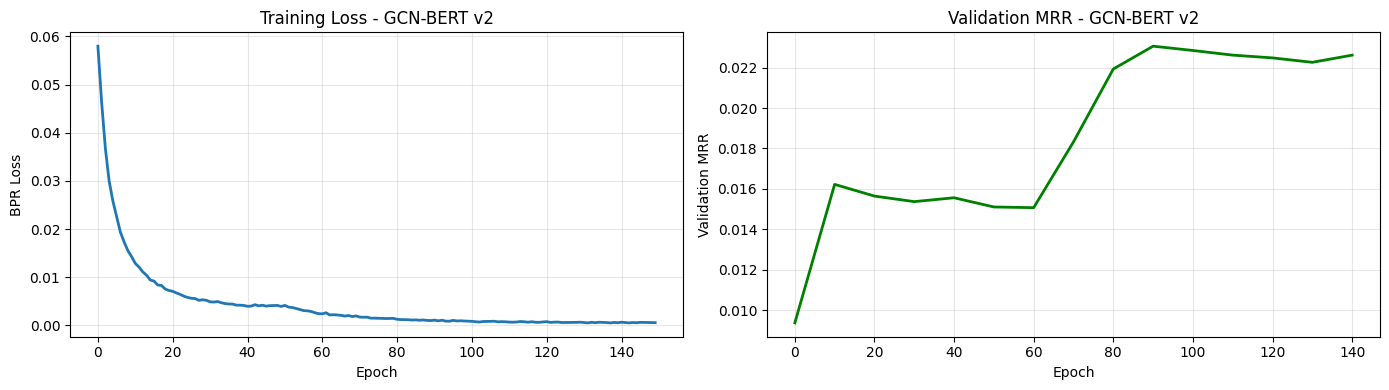


Evaluando GCN-BERT v2 en test...

Métricas GCN-BERT v2 (test):
  MRR: 0.015343
  ILD: 0.938621
  Coverage: 1.000000


In [21]:
model_gcn_bert = GCNRecommenderV2(
    num_users, num_train_items,
    train_item_embeddings_bert.shape[1],
    EMBED_DIM, HIDDEN_DIM, DROPOUT
).to(device)

optimizer = torch.optim.Adam(model_gcn_bert.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=2)
early_stopping = EarlyStopping(patience=PATIENCE)

print(f"GCN-BERT v2: {sum(p.numel() for p in model_gcn_bert.parameters()):,} params")

losses_gcn_bert = []
val_mrrs = []

print("\nEntrenando GCN-BERT v2...")
for epoch in tqdm(range(MAX_EPOCHS)):
    loss = train_epoch_improved(model_gcn_bert, train_edge_index, train_item_embeddings_bert,
                                train_df, neg_dict, optimizer, False, 0.0)
    losses_gcn_bert.append(loss)
    scheduler.step()

    if epoch % 10 == 0:
        recs_val, gt_val, active_users_val = evaluate_cold_start_v2(
            model_gcn_bert, train_edge_index,
            train_item_embeddings_bert, val_item_embeddings_bert,
            val_df, False, False, 10
        )
        metrics_val = compute_metrics(recs_val, gt_val, num_val_items)
        val_mrrs.append(metrics_val['MRR'])

        early_stopping(metrics_val['MRR'], model_gcn_bert)
        if early_stopping.early_stop:
            print(f"\nEarly stopping en epoch {epoch}")
            break

model_gcn_bert.load_state_dict({k: v.to(device) for k, v in early_stopping.best_model_state.items()})

plt.figure(figsize=(14, 4))
plt.subplot(1, 2, 1)
plt.plot(losses_gcn_bert, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title('Training Loss - GCN-BERT v2')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(0, len(losses_gcn_bert), 10)[:len(val_mrrs)], val_mrrs, linewidth=2, color='green')
plt.xlabel('Epoch')
plt.ylabel('Validation MRR')
plt.title('Validation MRR - GCN-BERT v2')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEvaluando GCN-BERT v2 en test...")
recs_gcn_bert, gt_test, active_users_test = evaluate_cold_start_v2(
    model_gcn_bert, train_edge_index,
    train_item_embeddings_bert, test_item_embeddings_bert,
    test_df, False, False, 10
)
metrics_gcn_bert = compute_metrics(recs_gcn_bert, gt_test, num_test_items)
test_user_ids = sorted(gt_test.keys())

print("\nMétricas GCN-BERT v2 (test):")
for k, v in metrics_gcn_bert.items():
    print(f"  {k}: {v:.6f}")

## Entrenar GCN-Random v2

Con embeddings entrenables de 128-dim, BatchNorm, Dropout, 4 capas.

GCN-Random v2: 5,260,480 params

Entrenando GCN-Random v2...


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch 50, Loss: 0.0055
Epoch 100, Loss: 0.0023


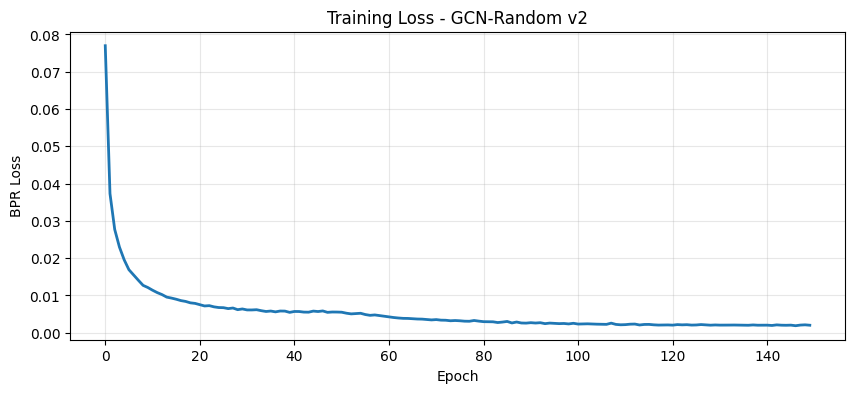


Nota: GCN-Random no se puede evaluar en cold-start items (no hay features).
Para usar GCN-Random en test, necesitamos generar random embeddings fijos para items cold.

Métricas GCN-Random v2 (test):
  MRR: 0.014257
  ILD: 0.970763
  Coverage: 1.000000


In [22]:
model_gcn_random = GCNRecommenderRandomV2(
    num_users, num_train_items,
    EMBED_DIM, HIDDEN_DIM, DROPOUT
).to(device)

optimizer = torch.optim.Adam(model_gcn_random.parameters(), lr=LR, weight_decay=WD)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=2)
early_stopping = EarlyStopping(patience=PATIENCE)

print(f"GCN-Random v2: {sum(p.numel() for p in model_gcn_random.parameters()):,} params")

losses_gcn_random = []

print("\nEntrenando GCN-Random v2...")
for epoch in tqdm(range(MAX_EPOCHS)):
    loss = train_epoch_improved(model_gcn_random, train_edge_index, None,
                                train_df, neg_dict, optimizer, True, 0.1)
    losses_gcn_random.append(loss)
    scheduler.step()

    if epoch % 10 == 0 and epoch > 0:
        if epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(losses_gcn_random, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('BPR Loss')
plt.title('Training Loss - GCN-Random v2')
plt.grid(True, alpha=0.3)
plt.show()

print("\nNota: GCN-Random no se puede evaluar en cold-start items (no hay features).")
print("Para usar GCN-Random en test, necesitamos generar random embeddings fijos para items cold.")

test_item_embeddings_random = torch.empty(num_test_items, EMBED_DIM).to(device)
nn.init.xavier_uniform_(test_item_embeddings_random)
test_item_embeddings_random = F.normalize(test_item_embeddings_random, p=2, dim=1)

model_gcn_random.eval()
with torch.no_grad():
    user_emb, _ = model_gcn_random(train_edge_index)
    scores_matrix = torch.matmul(user_emb, test_item_embeddings_random.t())
    recs_gcn_random_all = {}
    for user_idx in range(num_users):
        _, top = torch.topk(scores_matrix[user_idx], 10)
        recs_gcn_random_all[user_idx] = top.cpu().tolist()

recs_gcn_random = {u: recs_gcn_random_all.get(u, []) for u in test_user_ids}
metrics_gcn_random = compute_metrics(recs_gcn_random, gt_test, num_test_items)

print("\nMétricas GCN-Random v2 (test):")
for k, v in metrics_gcn_random.items():
    print(f"  {k}: {v:.6f}")

## Entrenar LightGCN v2

Con projection propia para cold-start, normalización L2 por capa, 4 capas.

In [29]:
def run_lightgcn_experiment(config, seed=42, verbose=False):
    cfg = {
        'embedding_dim': config.get('embedding_dim', EMBED_DIM),
        'num_layers': config.get('num_layers', 4),
        'lr': config.get('lr', LR),
        'weight_decay': config.get('weight_decay', WD),
        'patience': config.get('patience', PATIENCE),
        'max_epochs': config.get('max_epochs', MAX_EPOCHS),
        'scheduler_T0': config.get('scheduler_T0', 50),
        'scheduler_Tmult': config.get('scheduler_Tmult', 2),
        'val_every': config.get('val_every', 10)
    }

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = LightGCNV2(
        num_users, num_train_items,
        train_item_embeddings_bert.shape[1],
        cfg['embedding_dim'], cfg['num_layers']
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=cfg['scheduler_T0'], T_mult=cfg['scheduler_Tmult']
    )
    early_stopping = EarlyStopping(patience=cfg['patience'])

    user_ids_np = train_df['user_idx'].values
    item_ids_np = train_df['item_idx'].values
    weights_np = train_df['interaction_count'].values if 'interaction_count' in train_df.columns else np.ones(len(train_df))
    weights_np = weights_np / weights_np.max()

    pos_users = torch.LongTensor(user_ids_np).to(device)
    pos_items = torch.LongTensor(item_ids_np).to(device)
    weights_t = torch.FloatTensor(weights_np).to(device)

    losses = []
    val_history = []
    best_val = -float('inf')
    best_epoch = 0

    for epoch in range(cfg['max_epochs']):
        model.train()
        optimizer.zero_grad()

        user_emb, item_emb = model(train_edge_index, train_item_embeddings_bert)

        neg_items = []
        for u in user_ids_np:
            if u in neg_dict and neg_dict[u]:
                neg_i = random.choice(neg_dict[u])
            else:
                neg_i = random.randint(0, model.num_items - 1)
            neg_items.append(neg_i)
        neg_items_t = torch.LongTensor(neg_items).to(device)

        pos_scores = (user_emb[pos_users] * item_emb[pos_items]).sum(dim=1)
        neg_scores = (user_emb[pos_users] * item_emb[neg_items_t]).sum(dim=1)
        loss = -(torch.sigmoid(pos_scores - neg_scores).log() * weights_t).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

        if epoch % cfg['val_every'] == 0 or epoch == cfg['max_epochs'] - 1:
            recs_val, gt_val, _ = evaluate_cold_start_v2(
                model, train_edge_index,
                train_item_embeddings_bert, val_item_embeddings_bert,
                val_df, False, True, 10
            )
            metrics_val = compute_metrics(recs_val, gt_val, num_val_items)
            val_history.append((epoch, metrics_val['MRR']))

            if verbose:
                print(f"Epoch {epoch:03d} | Loss {loss.item():.4f} | Val MRR {metrics_val['MRR']:.5f}")

            early_stopping(metrics_val['MRR'], model)
            if metrics_val['MRR'] > best_val:
                best_val = metrics_val['MRR']
                best_epoch = epoch

            if early_stopping.early_stop:
                if verbose:
                    print(f"\nEarly stopping en epoch {epoch}")
                break

    if early_stopping.best_model_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in early_stopping.best_model_state.items()})

    recs_test_raw, _, _ = evaluate_cold_start_v2(
        model, train_edge_index,
        train_item_embeddings_bert, test_item_embeddings_bert,
        test_df, False, True, 10
    )
    recs_test = {u: recs_test_raw.get(u, []) for u in test_user_ids}
    metrics_test = compute_metrics(recs_test, gt_test, num_test_items)

    return {
        'config': cfg,
        'best_val_mrr': float(best_val),
        'best_epoch': best_epoch,
        'val_history': val_history,
        'loss_history': losses,
        'test_metrics': metrics_test,
        'recs_test': recs_test
    }

In [30]:
lightgcn_search_space = [
    {'name': 'dim128_l4_base', 'embedding_dim': 128, 'num_layers': 4, 'lr': 1e-3, 'max_epochs': 150, 'patience': 20},
    {'name': 'dim192_l3',      'embedding_dim': 192, 'num_layers': 3, 'lr': 1e-3, 'max_epochs': 180, 'patience': 25},
    {'name': 'dim192_l4_lr5e-4', 'embedding_dim': 192, 'num_layers': 4, 'lr': 5e-4, 'max_epochs': 200, 'patience':
30},
    {'name': 'dim256_l3',      'embedding_dim': 256, 'num_layers': 3, 'lr': 7.5e-4, 'max_epochs': 200, 'patience': 25}
]

lightgcn_runs = []
for cfg in lightgcn_search_space:
    print(f"\n### Ejecutando LightGCN: {cfg['name']}")
    run_cfg = {k: v for k, v in cfg.items() if k != 'name'}
    result = run_lightgcn_experiment(run_cfg, seed=42, verbose=False)
    result['name'] = cfg['name']
    print(f"  Val MRR:  {result['best_val_mrr']:.5f}")
    print(f"  Test MRR: {result['test_metrics']['MRR']:.5f}")
    lightgcn_runs.append(result)

results_df = pd.DataFrame([
    {
        'run': r['name'],
        'embedding_dim': r['config']['embedding_dim'],
        'num_layers': r['config']['num_layers'],
        'lr': r['config']['lr'],
        'weight_decay': r['config']['weight_decay'],
        'max_epochs': r['config']['max_epochs'],
        'patience': r['config']['patience'],
        'best_val_mrr': r['best_val_mrr'],
        'test_mrr': r['test_metrics']['MRR'],
        'test_ild': r['test_metrics']['ILD'],
        'test_coverage': r['test_metrics']['Coverage'],
        'best_epoch': r['best_epoch']
    }
    for r in lightgcn_runs
])
display(results_df.sort_values('best_val_mrr', ascending=False))

best_lightgcn_run = max(lightgcn_runs, key=lambda r: r['best_val_mrr'])
recs_lightgcn = best_lightgcn_run['recs_test']
metrics_lightgcn = best_lightgcn_run['test_metrics']

print("\nMejor configuración LightGCN:")
for key in ['embedding_dim', 'num_layers', 'lr', 'weight_decay', 'max_epochs', 'patience']:
    print(f"  {key}: {best_lightgcn_run['config'][key]}")
print(f"  Val MRR:  {best_lightgcn_run['best_val_mrr']:.5f}")
print(f"  Test MRR: {metrics_lightgcn['MRR']:.5f}")
print(f"  Test ILD: {metrics_lightgcn['ILD']:.5f}")


### Ejecutando LightGCN: dim128_l4_base
  Val MRR:  0.08024
  Test MRR: 0.03091

### Ejecutando LightGCN: dim192_l3
  Val MRR:  0.08346
  Test MRR: 0.02698

### Ejecutando LightGCN: dim192_l4_lr5e-4
  Val MRR:  0.08461
  Test MRR: 0.03466

### Ejecutando LightGCN: dim256_l3
  Val MRR:  0.08339
  Test MRR: 0.02735


,run,embedding_dim,num_layers,lr,weight_decay,max_epochs,patience,best_val_mrr,test_mrr,test_ild,test_coverage,best_epoch
2,dim192_l4_lr5e-4,192,4,0.00050,0.00001,200,30,0.084615,0.034658,0.910106,1.0,50
1,dim192_l3,192,3,0.00100,0.00001,180,25,0.083462,0.026976,0.911814,1.0,10
3,dim256_l3,256,3,0.00075,0.00001,200,25,0.083394,0.027351,0.908682,1.0,10
0,dim128_l4_base,128,4,0.00100,0.00001,150,20,0.080243,0.030907,0.929335,1.0,10



Mejor configuración LightGCN:
  embedding_dim: 192
  num_layers: 4
  lr: 0.0005
  weight_decay: 1e-05
  max_epochs: 200
  patience: 30
  Val MRR:  0.08461
  Test MRR: 0.03466
  Test ILD: 0.91011


## Comparación de modelos mejorados


COMPARACIÓN - MODELOS MEJORADOS (cold-start items)
                    MRR       ILD  Coverage
GCN-BERT v2    0.015343  0.938621       1.0
GCN-Random v2  0.014257  0.970763       1.0
LightGCN v2    0.034658  0.910106       1.0


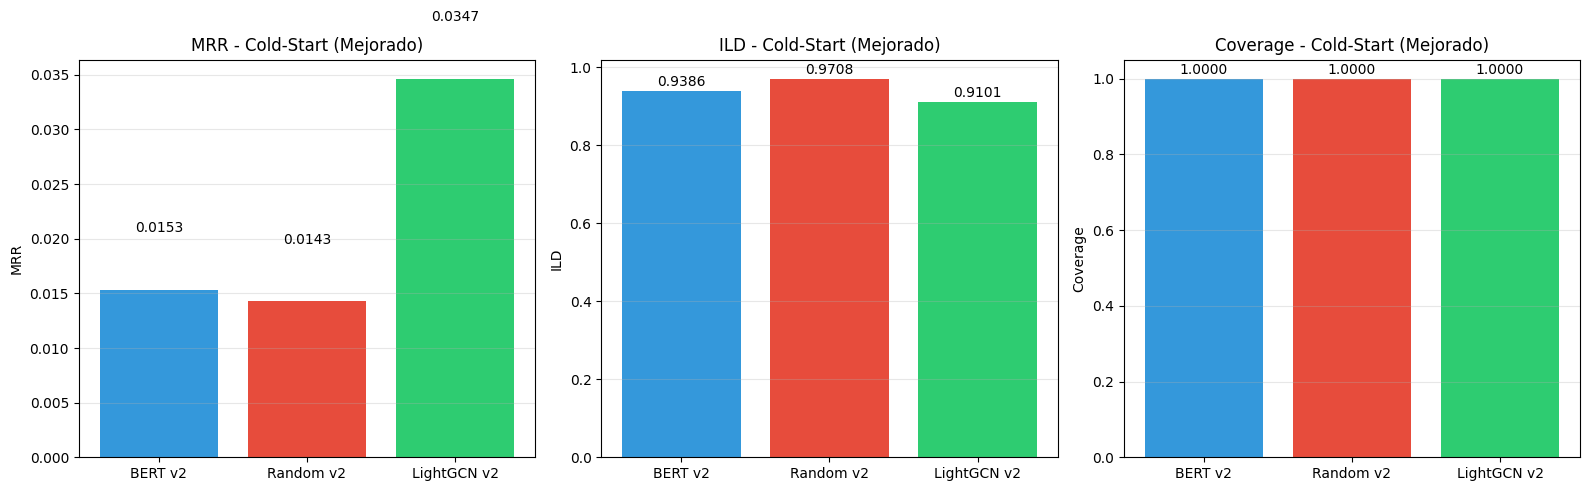


Cobertura por modelo (top-k)


,Coverage@3,Coverage@5,Coverage@10
Modelo,,,
GCN-BERT v2,0.961672,0.986063,1.0
GCN-Random v2,0.979094,0.993031,1.0
LightGCN v2,0.996516,1.000000,1.0


In [36]:
comparison = pd.DataFrame({
    'GCN-BERT v2': metrics_gcn_bert,
    'GCN-Random v2': metrics_gcn_random,
    'LightGCN v2': metrics_lightgcn
})

print("\n" + "=" * 70)
print("COMPARACIÓN - MODELOS MEJORADOS (cold-start items)")
print("=" * 70)
print(comparison.T.to_string())
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_names = ['MRR', 'ILD', 'Coverage']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, metric in enumerate(metrics_names):
    values = [metrics_gcn_bert[metric], metrics_gcn_random[metric], metrics_lightgcn[metric]]
    axes[i].bar(['BERT v2', 'Random v2', 'LightGCN v2'], values, color=colors)
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'{metric} - Cold-Start (Mejorado)')
    axes[i].grid(True, alpha=0.3, axis='y')
    for j, v in enumerate(values):
        axes[i].text(j, v + 0.005, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

def coverage_at_k(recommendations, num_items, k):
    seen = set()
    for rec_list in recommendations.values():
        seen.update(rec_list[:k])
    return len(seen) / num_items if num_items > 0 else 0.0

coverage_rows = []
for name, recs in [
    ('GCN-BERT v2', recs_gcn_bert),
    ('GCN-Random v2', recs_gcn_random),
    ('LightGCN v2', recs_lightgcn),
]:
    coverage_rows.append({
        'Modelo': name,
        'Coverage@3': coverage_at_k(recs, num_test_items, 3),
        'Coverage@5': coverage_at_k(recs, num_test_items, 5),
        'Coverage@10': coverage_at_k(recs, num_test_items, 10),
    })

coverage_df = pd.DataFrame(coverage_rows).set_index('Modelo')
print("\nCobertura por modelo (top-k)")
display(coverage_df)

## Análisis de desinformación (igual que v1)

In [37]:
labels_test = test_df.groupby('source_tree_id')[['tree_label', 'parent_label']].first().to_dict()
labels_dict = {iid: labels_test['tree_label'].get(iid, 'NR') for iid in test_items_cold}

def analyze_label_distribution(recommendations, item_idx_to_id):
    label_counts = {'TR': 0, 'FR': 0, 'UR': 0, 'NR': 0}
    total = 0
    for rec_list in recommendations.values():
        for item_idx in rec_list:
            item_id = item_idx_to_id.get(item_idx)
            if item_id:
                label = labels_dict.get(item_id, 'NR')
                if label in label_counts:
                    label_counts[label] += 1
                total += 1
    return {k: v/total*100 if total > 0 else 0 for k, v in label_counts.items()}

item_idx_to_id_test = {v: k for k, v in item_to_idx_test.items()}

dist_gcn_bert = analyze_label_distribution(recs_gcn_bert, item_idx_to_id_test)
dist_gcn_random = analyze_label_distribution(recs_gcn_random, item_idx_to_id_test)
dist_lightgcn = analyze_label_distribution(recs_lightgcn, item_idx_to_id_test)

baseline_dist = test_df['tree_label'].value_counts(normalize=True).to_dict()
baseline_dist = {k: v*100 for k, v in baseline_dist.items()}

print("\n" + "="*70)
print("DISTRIBUCIÓN DE LABELS (items cold-start de test)")
print("="*70)

dist_df = pd.DataFrame({
    'Test Dataset': baseline_dist,
    'GCN-BERT v2': dist_gcn_bert,
    'GCN-Random v2': dist_gcn_random,
    'LightGCN v2': dist_lightgcn
})

print(dist_df.T.to_string())
print("="*70)


DISTRIBUCIÓN DE LABELS (items cold-start de test)
                      FR         UR         TR        NR
Test Dataset   57.390721  21.036235  19.866756  1.706288
GCN-BERT v2    50.525088  37.580919   9.006360  2.887633
GCN-Random v2  59.619788  20.361131  16.961131  3.057951
LightGCN v2    67.492580  17.447350  14.225442  0.834629


## Identificar usuarios expuestos

In [38]:
def identify_exposed_users(recommendations, item_idx_to_id, target_labels=['FR']):
    exposed = set()
    for user_idx, rec_list in recommendations.items():
        for item_idx in rec_list[:10]:
            item_id = item_idx_to_id.get(item_idx)
            if item_id:
                label = labels_dict.get(item_id, 'NR')
                if label in target_labels:
                    exposed.add(user_idx)
                    break
    return exposed

exposed_gcn_bert = identify_exposed_users(recs_gcn_bert, item_idx_to_id_test, ['FR'])
exposed_gcn_random = identify_exposed_users(recs_gcn_random, item_idx_to_id_test, ['FR'])
exposed_lightgcn = identify_exposed_users(recs_lightgcn, item_idx_to_id_test, ['FR'])

total_eval_users = len(gt_test)

print(f"\nUsuarios expuestos a fake news (FR):")
print(f"  GCN-BERT v2:   {len(exposed_gcn_bert)} ({len(exposed_gcn_bert)/total_eval_users*100:.2f}%)")
print(f"  GCN-Random v2: {len(exposed_gcn_random)} ({len(exposed_gcn_random)/total_eval_users*100:.2f}%)")
print(f"  LightGCN v2:   {len(exposed_lightgcn)} ({len(exposed_lightgcn)/total_eval_users*100:.2f}%)")


Usuarios expuestos a fake news (FR):
  GCN-BERT v2:   13254 (93.67%)
  GCN-Random v2: 14150 (100.00%)
  LightGCN v2:   14010 (99.01%)


## Congelar resultados actuales
  Guardamos las salidas de los modelos GNN ya entrenados para reutilizarlas en los análisis y comparaciones con los
  baselines clásicos

In [39]:
if 'model_results' not in globals():
    model_results = {}

model_results.update({
    'GCN-BERT v2': {'metrics': metrics_gcn_bert, 'recs': recs_gcn_bert},
    'GCN-Random v2': {'metrics': metrics_gcn_random, 'recs': recs_gcn_random},
    'LightGCN v2': {'metrics': metrics_lightgcn, 'recs': recs_lightgcn},
})
print(f"Modelos registrados: {list(model_results.keys())}")

Modelos registrados: ['GCN-BERT v2', 'GCN-Random v2', 'LightGCN v2']


## Baselines clásicos para cold-start

  Reutilizamos el split temporal y los embeddings MPNet para implementar:
  - `MostPopular` (popularidad por similitud global de contenido)
  - `Random`
  - `ItemKNN` (similaridad ítem–ítem con MPNet)
  - `UserKNN` (vecindario en el espacio de perfiles MPNet por usuario)
  - `TF-IDF` (perfiles de usuario con bolsa de palabras)

  Todos evalúan exactamente los mismos usuarios e ítems que los modelos GNN.

In [40]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix, diags

rng = np.random.default_rng(42)

# Ground truth y usuarios evaluados
if 'gt_test' not in globals():
    gt_test = {}
    for user_idx, group in test_df.groupby('user_idx'):
        gt_test[user_idx] = set(group['item_idx_cold'].values)
if 'test_user_ids' not in globals():
    test_user_ids = sorted(gt_test.keys())

num_eval_users = len(test_user_ids)
print(f"Usuarios con interacciones en test: {num_eval_users}")

# Matriz usuario-item de entrenamiento
train_matrix = csr_matrix(
    (np.ones(len(train_df)), (train_df['user_idx'], train_df['item_idx'])),
    shape=(num_users, num_train_items)
)

# Embeddings MPNet a numpy
train_item_emb_np = train_item_embeddings_bert.detach().cpu().numpy()
test_item_emb_np = test_item_embeddings_bert.detach().cpu().numpy()

# Historiales por usuario
user_histories = train_df.groupby('user_idx')['item_idx'].apply(list).to_dict()

# Perfiles MPNet promedio por usuario
embedding_dim = train_item_emb_np.shape[1]
user_profiles = np.zeros((num_users, embedding_dim), dtype=np.float32)
user_counts = np.zeros(num_users, dtype=np.int32)

for u, i in zip(train_df['user_idx'].values, train_df['item_idx'].values):
    user_profiles[u] += train_item_emb_np[i]
    user_counts[u] += 1

nonzero_mask = user_counts > 0
user_profiles[nonzero_mask] /= user_counts[nonzero_mask][:, None]
norms = np.linalg.norm(user_profiles, axis=1, keepdims=True)
norms[norms == 0] = 1.0
user_profiles = user_profiles / norms

user_item_scores = user_profiles @ test_item_emb_np.T  # cosenos user→item

# Textos limpios para TF-IDF (se regeneran si no existen en memoria)
if 'ordered_texts_train' not in globals():
    item_texts_train = train_df.groupby('source_tree_id')['text'].first().to_dict()
    ordered_texts_train = [clean_tweet_text(item_texts_train.get(item, "")) for item in train_items_list]

if 'ordered_texts_test' not in globals():
    item_texts_test = test_df.groupby('source_tree_id')['text'].first().to_dict()
    ordered_texts_test = [clean_tweet_text(item_texts_test.get(item, "")) for item in test_items_cold]

Usuarios con interacciones en test: 14150


In [41]:
baseline_recs = {}

# 1) MostPopular (similaridad global de contenido)
global_profile = train_item_emb_np.mean(axis=0)
global_profile /= np.linalg.norm(global_profile)
global_scores = test_item_emb_np @ global_profile
global_ranking = np.argsort(-global_scores)
baseline_recs['MostPopular'] = {u: global_ranking[:10].tolist() for u in test_user_ids}

# 2) Random
baseline_recs['Random'] = {
    u: rng.choice(num_test_items, size=10, replace=False).tolist()
    for u in test_user_ids
}

# 3) ItemKNN (top vecinos ítem–ítem en espacio MPNet)
similarity_matrix = test_item_emb_np @ train_item_emb_np.T  # (num_test_items x num_train_items)

def build_item_knn_recs(top_neighbors=30):
    recs = {}
    fallback = global_ranking[:10].tolist()
    for user_idx in test_user_ids:
        history = user_histories.get(user_idx, [])
        if not history:
            recs[user_idx] = fallback
            continue
        sims = similarity_matrix[:, history]
        sims = sims.reshape(num_test_items, -1)
        if sims.shape[1] > top_neighbors:
            topk = np.partition(sims, -top_neighbors, axis=1)[:, -top_neighbors:]
        else:
            topk = sims
        scores = topk.mean(axis=1)
        recs[user_idx] = np.argsort(-scores)[:10].tolist()
    return recs

baseline_recs['ItemKNN'] = build_item_knn_recs(top_neighbors=30)

# 4) UserKNN (vecinos en perfiles MPNet)
active_users = np.where(nonzero_mask)[0]
if len(active_users) > 0:
    nn_k = min(50, len(active_users))
    nn_model = NearestNeighbors(n_neighbors=nn_k, metric='cosine')
    nn_model.fit(user_profiles[active_users])
    distances, indices = nn_model.kneighbors(user_profiles[active_users], return_distance=True)
    cosine_sim = 1 - distances

    neighbor_dict = {}
    for row_idx, user_idx in enumerate(active_users):
        neigh_users = active_users[indices[row_idx]]
        sims = cosine_sim[row_idx]
        neighbor_dict[user_idx] = [
            (int(n), float(s))
            for n, s in zip(neigh_users, sims)
            if n != user_idx and s > 0
        ]
else:
    neighbor_dict = {}

fallback = global_ranking[:10].tolist()
user_knn_recs = {}
for user_idx in test_user_ids:
    neighbors = neighbor_dict.get(user_idx, [])
    if neighbors:
        scores = np.zeros(num_test_items, dtype=np.float32)
        total_weight = 0.0
        for neigh, sim in neighbors:
            scores += sim * user_item_scores[neigh]
            total_weight += sim
        if total_weight > 0:
            scores /= total_weight
        else:
            scores = user_item_scores[user_idx]
    else:
        scores = user_item_scores[user_idx] if user_counts[user_idx] > 0 else global_scores
    user_knn_recs[user_idx] = np.argsort(-scores)[:10].tolist()
baseline_recs['UserKNN'] = user_knn_recs

# 5) TF-IDF (bolsa de palabras + promedios de usuario)
vectorizer = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2))
tfidf_train = vectorizer.fit_transform(ordered_texts_train)
tfidf_test = vectorizer.transform(ordered_texts_test)

user_counts_safe = train_matrix.sum(axis=1).A1
user_counts_safe[user_counts_safe == 0] = 1
user_tfidf_profiles = diags(1.0 / user_counts_safe) @ train_matrix @ tfidf_train
tfidf_scores = (user_tfidf_profiles[test_user_ids] @ tfidf_test.T).toarray()

tfidf_recs = {}
for row_idx, user_idx in enumerate(test_user_ids):
    scores = tfidf_scores[row_idx]
    tfidf_recs[user_idx] = np.argsort(-scores)[:10].tolist()
baseline_recs['TF-IDF'] = tfidf_recs

print("Baselines generados:", list(baseline_recs.keys()))

Baselines generados: ['MostPopular', 'Random', 'ItemKNN', 'UserKNN', 'TF-IDF']


In [42]:
for name, recs in baseline_recs.items():
    metrics = compute_metrics(recs, gt_test, num_test_items)
    model_results[name] = {'metrics': metrics, 'recs': recs}
    print(f"{name:>12} → Test MRR {metrics['MRR']:.5f} | ILD {metrics['ILD']:.5f} | Coverage {metrics['Coverage']:.5f}")

 MostPopular → Test MRR 0.01188 | ILD 0.00000 | Coverage 0.03484
      Random → Test MRR 0.01535 | ILD 0.98136 | Coverage 1.00000
     ItemKNN → Test MRR 0.03465 | ILD 0.83143 | Coverage 0.98258
     UserKNN → Test MRR 0.03383 | ILD 0.81965 | Coverage 0.95122
      TF-IDF → Test MRR 0.02834 | ILD 0.87065 | Coverage 0.99652


## Comparación global de modelos

  Todos los métodos (GNN y baselines) se evalúan sobre exactamente el mismo split cold-start. A continuación se resume
  MRR/ILD/Coverage y se añade un desglose de cobertura @k, distribución de labels y exposición a fake news.

,MRR,ILD,Coverage
LightGCN v2,0.034658,0.910106,1.000000
ItemKNN,0.034654,0.831434,0.982578
UserKNN,0.033828,0.819654,0.951220
TF-IDF,0.028338,0.870646,0.996516
Random,0.015348,0.981361,1.000000
GCN-BERT v2,0.015343,0.938621,1.000000
GCN-Random v2,0.014257,0.970763,1.000000
MostPopular,0.011885,0.000000,0.034843


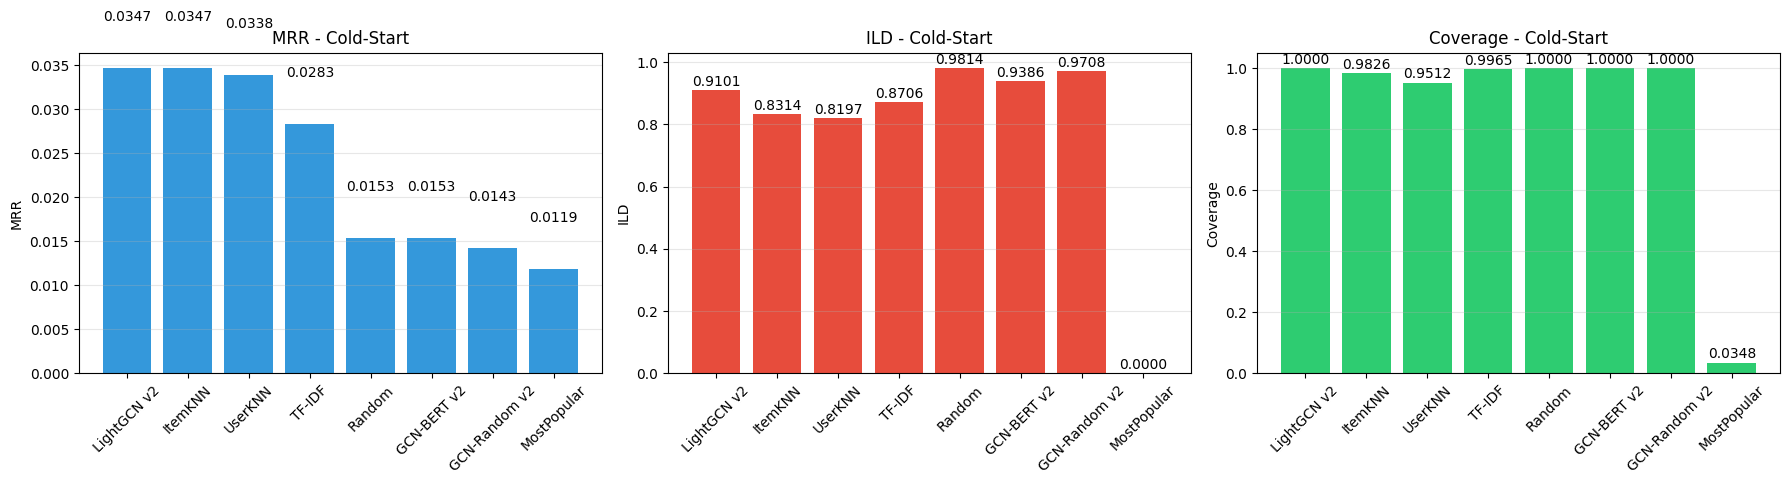

,Coverage@3,Coverage@5,Coverage@10
Modelo,,,
LightGCN v2,0.996516,1.000000,1.000000
ItemKNN,0.891986,0.958188,0.982578
UserKNN,0.783972,0.881533,0.951220
TF-IDF,0.996516,0.996516,0.996516
Random,1.000000,1.000000,1.000000
GCN-BERT v2,0.961672,0.986063,1.000000
GCN-Random v2,0.979094,0.993031,1.000000
MostPopular,0.010453,0.017422,0.034843


In [43]:
import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    name: res['metrics'] for name, res in model_results.items()
}).T[['MRR', 'ILD', 'Coverage']]

comparison_df = comparison_df.sort_values('MRR', ascending=False)
display(comparison_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_names = ['MRR', 'ILD', 'Coverage']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, metric in enumerate(metrics_names):
    axes[i].bar(comparison_df.index, comparison_df[metric], color=colors[i])
    axes[i].set_ylabel(metric)
    axes[i].set_title(f'{metric} - Cold-Start')
    axes[i].tick_params(axis='x', rotation=45)
    for j, v in enumerate(comparison_df[metric]):
        axes[i].text(j, v + 0.005, f'{v:.4f}', ha='center', va='bottom')
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

def coverage_at_k(recommendations, num_items, k):
    seen = set()
    for rec_list in recommendations.values():
        seen.update(rec_list[:k])
    return len(seen) / num_items if num_items > 0 else 0.0

coverage_rows = []
for name in comparison_df.index:
    recs = model_results[name]['recs']
    coverage_rows.append({
        'Modelo': name,
        'Coverage@3': coverage_at_k(recs, num_test_items, 3),
        'Coverage@5': coverage_at_k(recs, num_test_items, 5),
        'Coverage@10': coverage_at_k(recs, num_test_items, 10),
    })

coverage_df = pd.DataFrame(coverage_rows).set_index('Modelo')
display(coverage_df)

In [44]:
labels_test = test_df.groupby('source_tree_id')[['tree_label', 'parent_label']].first().to_dict()
labels_dict = {iid: labels_test['tree_label'].get(iid, 'NR') for iid in test_items_cold}
item_idx_to_id_test = {v: k for k, v in item_to_idx_test.items()}

def analyze_label_distribution_dict(recommendations, item_idx_to_id):
    label_counts = {'TR': 0, 'FR': 0, 'UR': 0, 'NR': 0}
    total = 0
    for rec_list in recommendations.values():
        for item_idx in rec_list:
            item_id = item_idx_to_id.get(item_idx)
            if item_id:
                label = labels_dict.get(item_id, 'NR')
                if label in label_counts:
                    label_counts[label] += 1
                total += 1
    return {k: v/total*100 if total > 0 else 0 for k, v in label_counts.items()}

baseline_dist = test_df['tree_label'].value_counts(normalize=True).to_dict()
baseline_dist = {k: v*100 for k, v in baseline_dist.items()}

dist_rows = {'Test Dataset': baseline_dist}
for name in comparison_df.index:
    dist_rows[name] = analyze_label_distribution_dict(model_results[name]['recs'], item_idx_to_id_test)

dist_df = pd.DataFrame(dist_rows).T.fillna(0.0)
print("\nDistribución de labels en las recomendaciones (%)")
display(dist_df)


Distribución de labels en las recomendaciones (%)


,FR,UR,TR,NR
Test Dataset,57.390721,21.036235,19.866756,1.706288
LightGCN v2,67.492580,17.447350,14.225442,0.834629
ItemKNN,56.041696,33.106007,9.354770,1.497527
UserKNN,55.443816,33.757597,9.398587,1.400000
TF-IDF,70.596466,12.195760,15.397880,1.809894
Random,58.993640,21.781625,16.758304,2.466431
GCN-BERT v2,50.525088,37.580919,9.006360,2.887633
GCN-Random v2,59.619788,20.361131,16.961131,3.057951
MostPopular,50.000000,50.000000,0.000000,0.000000


In [45]:
def identify_exposed_users_dict(recommendations, item_idx_to_id, target_labels=('FR',)):
    exposed = set()
    for user_idx, rec_list in recommendations.items():
        for item_idx in rec_list[:10]:
            item_id = item_idx_to_id.get(item_idx)
            if item_id:
                label = labels_dict.get(item_id, 'NR')
                if label in target_labels:
                    exposed.add(user_idx)
                    break
    return exposed

exposure_rows = []
total_eval_users = len(gt_test)
for name in comparison_df.index:
    exposed = identify_exposed_users_dict(model_results[name]['recs'], item_idx_to_id_test, ('FR',))
    exposure_rows.append({
        'Modelo': name,
        'Usuarios expuestos': len(exposed),
        'Porcentaje': len(exposed) / total_eval_users * 100
    })

exposure_df = pd.DataFrame(exposure_rows).set_index('Modelo')
print("\nUsuarios expuestos a fake news (FR) en top-10")
display(exposure_df)


Usuarios expuestos a fake news (FR) en top-10


,Usuarios expuestos,Porcentaje
Modelo,,
LightGCN v2,14010,99.010601
ItemKNN,13613,96.204947
UserKNN,13581,95.978799
TF-IDF,14081,99.512367
Random,14150,100.000000
GCN-BERT v2,13254,93.667845
GCN-Random v2,14150,100.000000
MostPopular,14150,100.000000


## Propagación con Linear Threshold Model
  Usamos el grafo social temporal y tomamos como semillas a los usuarios expuestos a fake news (`FR`) para estimar
  reach/depth con LTM.

In [54]:
import torch
import numpy as np
from torch_geometric.data import Data

class LinearThresholdModel:
    def __init__(self, graph: Data, seed: int = 42):
        self.graph = graph
        self.num_nodes = graph.num_nodes
        self.seed = seed
        self._build_adjacency()

    def _build_adjacency(self):
        self.out_neighbors = [[] for _ in range(self.num_nodes)]
        self.in_neighbors = [[] for _ in range(self.num_nodes)]
        self.edge_weights = {}

        edge_index = self.graph.edge_index.cpu().numpy()
        weights = self.graph.edge_weight.cpu().numpy() if hasattr(self.graph, 'edge_weight') else None

        for i in range(edge_index.shape[1]):
            src, dst = edge_index[0, i], edge_index[1, i]
            weight = weights[i] if weights is not None else 1.0

            self.out_neighbors[src].append(dst)
            self.in_neighbors[dst].append(src)
            self.edge_weights[(src, dst)] = weight

    def _normalize_influence(self, node: int):
        if not self.in_neighbors[node]:
            return {}

        influences = {}
        total_weight = sum(
            self.edge_weights.get((neighbor, node), 1.0)
            for neighbor in self.in_neighbors[node]
        )
        if total_weight == 0:
            return {}

        for neighbor in self.in_neighbors[node]:
            weight = self.edge_weights.get((neighbor, node), 1.0)
            influences[neighbor] = weight / total_weight
        return influences

    def simulate(self, seed_nodes, thresholds=None, max_iterations=100):
        seed_nodes = set(seed_nodes)
        if thresholds is None:
            np.random.seed(self.seed)
            thresholds = np.random.uniform(0.0, 1.0, self.num_nodes)

        activated = seed_nodes.copy()
        infection_rounds = [seed_nodes.copy()]
        newly_activated = seed_nodes.copy()

        for _ in range(max_iterations):
            if not newly_activated:
                break

            candidates = set()
            for node in newly_activated:
                candidates.update(self.out_neighbors[node])
            candidates -= activated

            next_activated = set()
            for candidate in candidates:
                influence = self._normalize_influence(candidate)
                total_influence = sum(
                    influence.get(neighbor, 0.0)
                    for neighbor in influence
                    if neighbor in activated
                )
                if total_influence >= thresholds[candidate]:
                    next_activated.add(candidate)

            if not next_activated:
                break

            activated.update(next_activated)
            infection_rounds.append(next_activated.copy())
            newly_activated = next_activated

        return infection_rounds

    def monte_carlo_propagation(self, seed_nodes, num_simulations=100):
        seed_nodes = set(seed_nodes)
        np.random.seed(self.seed)
        reaches, depths = [], []

        for _ in range(num_simulations):
            thresholds = np.random.uniform(0.0, 1.0, self.num_nodes)
            infection_rounds = self.simulate(seed_nodes, thresholds, max_iterations=50)
            all_infected = set().union(*infection_rounds) if infection_rounds else set()
            reaches.append(len(all_infected) / self.num_nodes)
            depths.append(len(infection_rounds))

        return {
            'mean_reach': np.mean(reaches),
            'std_reach': np.std(reaches),
            'mean_depth': np.mean(depths),
            'std_depth': np.std(depths),
            'max_reach': np.max(reaches),
            'min_reach': np.min(reaches)
        }

## Propagación con Linear Threshold Model
  Empleamos el grafo social temporal y tomamos como semillas a los usuarios expuestos a `FR` (top‑10) para estimar
  reach/depth vía LTM.

In [58]:
import os
if not os.path.exists('/content/IIC3633-Proyecto'):
    !git clone https://github.com/aLotOfGluten/IIC3633-Proyecto.git /content/IIC3633-Proyecto
os.chdir('/content/IIC3633-Proyecto')
print('Directorio actual:', os.getcwd())

Cloning into '/content/IIC3633-Proyecto'...
remote: Enumerating objects: 4540, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 4540 (delta 48), reused 55 (delta 16), pack-reused 4434 (from 1)
Receiving objects: 100% (4540/4540), 35.80 MiB | 19.35 MiB/s, done.
Resolving deltas: 100% (1931/1931), done.
Updating files: 100% (4717/4717), done.
Directorio actual: /content/IIC3633-Proyecto


In [63]:
import os
os.chdir('/content/IIC3633-Proyecto')
print('Directorio actual:', os.getcwd())

!python build_temporal_graphs.py

Directorio actual: /content/IIC3633-Proyecto
Loading temporal data...
Total interactions: 110732
Unique users: 39958
Unique items: 1386
Creating mappings (using ONLY train set)...

  IMPORTANTE: Mappings creados SOLO con train set
  Esto evita data leakage pero puede causar cold-start en val/test
Mapped: 39958 users, 1386 items

Filtering val/test to remove cold-start ITEMS (allowing new users)...
  Val: 682 → 682 (removed 0 cold-start items)
  Test: 5974 → 5974 (removed 0 cold-start items)
  Total users (including new users from val/test): 39958
Applying edge cap...
Interactions after cap: 103972
Building bipartite graph...
Building social graph...
Saving graphs...
Saving mappings...
Saving splits...

Bipartite graph:
  Nodes: 41344
  Edges: 207944

Social graph:
  Nodes: 39958
  Edges: 335458

Saved to midterm/graphs_per_user_temporal/


In [65]:
from pathlib import Path
import torch
from torch_geometric.data import Data

# Candidatos: primero graphs_temporal, luego graphs_per_user_temporal
graph_candidates = [
    Path('midterm/graphs_temporal/social_graph.pt'),
    Path('midterm/graphs_per_user_temporal/social_graph.pt'),
    Path('midterm/graphs_temporal_correct/social_graph.pt'),
]

social_graph_path = next((p.resolve() for p in graph_candidates if p.exists()), None)
if social_graph_path is None:
    raise FileNotFoundError(
        "No se encontró social_graph.pt. Ejecuta build_temporal_graphs.py o ajusta la ruta manualmente."
)

print(f"Grafo social detectado en: {social_graph_path}")

raw_graph = torch.load(social_graph_path)

if isinstance(raw_graph, Data):
    graph_data = raw_graph
elif isinstance(raw_graph, dict):
    edge_index = raw_graph['edge_index']
    edge_weight = raw_graph.get('edge_weight')
    num_nodes = raw_graph.get('num_nodes') or raw_graph.get('num_users')
    graph_data = Data(edge_index=edge_index, edge_weight=edge_weight, num_nodes=num_nodes)
else:
    raise TypeError(f"Formato no soportado: {type(raw_graph)}")

ltm_model = LinearThresholdModel(graph_data, seed=42)
print(f"Grafo social cargado con {ltm_model.num_nodes:,} nodos")

Grafo social detectado en: /content/IIC3633-Proyecto/midterm/graphs_per_user_temporal/social_graph.pt
Grafo social cargado con 39,958 nodos


### Semillas: usuarios expuestos a fake news
Utilizamos `identify_exposed_users_dict` para obtener los usuarios cuyo top‑10 contiene al menos un item con etiqueta
`FR`.

In [68]:
target_labels = ('FR',)

if 'identify_exposed_users_dict' not in globals():
  def identify_exposed_users_dict(recommendations, item_idx_to_id, target_labels=('FR',)):
      exposed = set()
      for user_idx, rec_list in recommendations.items():
          for item_idx in rec_list[:10]:
              item_id = item_idx_to_id.get(item_idx)
              if item_id:
                  label = labels_dict.get(item_id, 'NR')
                  if label in target_labels:
                      exposed.add(user_idx)
                      break
      return exposed

exposure_sets = {}
for name in comparison_df.index:
  recs = model_results[name]['recs']
  exposed_users = identify_exposed_users_dict(recs, item_idx_to_id_test, target_labels)
  exposure_sets[name] = exposed_users

exposure_summary = pd.DataFrame(
  {
      'Modelo': list(exposure_sets.keys()),
      'Seeds (usuarios)': [len(seeds) for seeds in exposure_sets.values()],
      'Frac. seeds / grafo social': [len(seeds) / ltm_model.num_nodes for seeds in exposure_sets.values()],
  }
).set_index('Modelo')

display(exposure_summary)

# Monte Carlo del LTM para cada modelo
ltm_results = {}
for name, seeds in exposure_sets.items():
  if not seeds:
      continue
  stats = ltm_model.monte_carlo_propagation(set(seeds), num_simulations=50)
  stats['seed_count'] = len(seeds)
  stats['seed_fraction'] = len(seeds) / ltm_model.num_nodes
  stats['mean_reach_abs'] = stats['mean_reach'] * ltm_model.num_nodes
  ltm_results[name] = stats

ltm_df = pd.DataFrame(ltm_results).T[
  ['seed_count', 'seed_fraction', 'mean_reach', 'mean_reach_abs', 'mean_depth',
    'std_reach', 'std_depth', 'max_reach', 'min_reach']
].sort_values('mean_reach', ascending=False)

display(ltm_df)

,Seeds (usuarios),Frac. seeds / grafo social
Modelo,,
LightGCN v2,14010,0.350618
ItemKNN,13613,0.340683
UserKNN,13581,0.339882
TF-IDF,14081,0.352395
Random,14150,0.354122
GCN-BERT v2,13254,0.331698
GCN-Random v2,14150,0.354122
MostPopular,14150,0.354122


,seed_count,seed_fraction,mean_reach,mean_reach_abs,mean_depth,std_reach,std_depth,max_reach,min_reach
GCN-Random v2,14150.0,0.354122,0.585886,23410.84,20.98,0.014546,6.031550,0.615146,0.551554
MostPopular,14150.0,0.354122,0.585886,23410.84,20.98,0.014546,6.031550,0.615146,0.551554
Random,14150.0,0.354122,0.585886,23410.84,20.98,0.014546,6.031550,0.615146,0.551554
TF-IDF,14081.0,0.352395,0.584569,23358.20,20.88,0.014388,6.101279,0.614670,0.551104
LightGCN v2,14010.0,0.350618,0.582954,23293.68,20.66,0.014731,6.354872,0.612718,0.549527
ItemKNN,13613.0,0.340683,0.574901,22971.88,20.82,0.014155,6.247207,0.605936,0.542495
GCN-BERT v2,13254.0,0.331698,0.574153,22942.02,21.60,0.014812,5.888973,0.605686,0.539516
UserKNN,13581.0,0.339882,0.573752,22925.98,20.94,0.014270,6.255909,0.605611,0.538691
